In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from idlpy import *
import cartopy.crs as ccrs
import cartopy.feature as cf

IDL 8.7.2 (linux x86_64 m64).
(c) 2019, Harris Geospatial Solutions, Inc.

Licensed for use by: NIWA - National Institute of Water and Atmospheric Research Ltd - Ashley
License: 335119


In [2]:
'''
Create vegetation land masks
'''
ERA5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/FWI_6month_fire_season_ERA5_resolution.nc')
d4pdf = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')
cam5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')

vege_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/vegetation/1951-2021.nc')
vege_ds['longitude'] = [lon + 360 for lon in vege_ds.longitude.data]
era5_combined = (vege_ds.lai_hv + vege_ds.lai_lv).max('time')
era5_vege_mask = era5_combined.where(era5_combined>3.5)

vege_ds_coarsened = vege_ds.coarsen(latitude=3,longitude=3,boundary='pad').mean()

cam5_vege = vege_ds_coarsened.interp(longitude=cam5.longitude, latitude=cam5.latitude, method="linear")
cam5_combined = (cam5_vege.lai_hv + cam5_vege.lai_lv).max('time')
cam5_vege_mask = cam5_combined.where(cam5_combined>3.5)

d4pdf_vege = vege_ds_coarsened.interp(longitude=d4pdf.longitude, latitude=d4pdf.latitude, method="linear")
d4pdf_combined = (d4pdf_vege.lai_hv + d4pdf_vege.lai_lv).max('time')
d4pdf_vege_mask = d4pdf_combined.where(d4pdf_combined>3.5)

box = [(32,55),(232,256)]

def get_linregress_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = np.polyfit([i for i in range(len(arr))],arr,deg=1)[0]
        
    return(result)


In [3]:
def detrend_dim(da, dim, deg=1):
    # detrend along a single dimension
    p = da.polyfit(dim=dim, deg=deg)
    fit = xr.polyval(da[dim], p.polyfit_coefficients)
    return (da - fit) + da.mean(dim)

def detrend(da, dims, deg=1):
    # detrend along multiple dimensions
    # only valid for linear detrending (deg=1)
    da_detrended = da
    for dim in dims:
        da_detrended = detrend_dim(da_detrended, dim, deg=deg)
    return da_detrended

In [4]:
def plot_saved_result(df,ax,font):
    
    print(len(df['Truncation']))
    
    ax.scatter(df['Truncation'],df['ant_best'],color='red',marker='.',label='ANT')
    ax.scatter(df['Truncation'],df['ant_upper'],color='red',marker='_')
    ax.scatter(df['Truncation'],df['ant_lower'],color='red',marker='_')
    ax.vlines(df['Truncation'],df['ant_lower'],df['ant_upper'],color='red')

    ax.scatter(df['Truncation'],df['nat_best'],color='blue',marker='.',label='NAT')
    ax.scatter(df['Truncation'],df['nat_upper'],color='blue',marker='_')
    ax.scatter(df['Truncation'],df['nat_lower'],color='blue',marker='_')
    ax.vlines(df['Truncation'],df['nat_lower'],df['nat_upper'],color='blue')

    ax.axhline(0,-0.5,1.5,c='black',alpha=0.8)
    ax.axhline(1,-0.5,1.5,c='black',alpha=0.8)
    ax.set_ylim(-1.5,4.5)
    
    font['size'] = 18
    ax.set_xlim(-1,45)
    ax.set_xticks([20*i for i in range(3)])
    ax.set_xticklabels([str(20*i) for i in range(3)],fontdict=font)
    font['size'] = 22
    
    #ax.set_title(str(scale),fontdict=font)
    
    #plt.savefig('/nesi/project/niwa00015/queenle/plots/fire/era5_fingerprinting/FWI/6month_fire_season/'+resample_interval+'/result.png')
    
    #plt.close(fig)
    

In [5]:
def plot_maps(all_array,nat_array,ant_array):
    
    box = [(32,55),(232,256)]
    
    era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
    ex_da = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')

    ex_da = ex_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
    ex_da = ex_da.where(cam5_vege_mask>0)
        
    ex_da = ex_da.sel(time=slice('1959','2014'))
    ex_da = ex_da.where(~era5_da.isnull())
    
    pixel = ex_da.stack(pixel=("latitude", "longitude"))
    no_nan = pixel.dropna("pixel", how="all")
    shape = no_nan.FWI.data.shape

    add_arrays = no_nan.assign(all_=(['time','lev','pixel'],all_array.reshape(shape)),
                                nat=(['time','lev','pixel'],nat_array.reshape(shape)),
                                ant=(['time','lev','pixel'],ant_array.reshape(shape))
                              )
    add_arrays.drop('FWI')
    unstack = add_arrays.unstack("pixel")
    
    fig,axs = plt.subplots(1,3,figsize=(16,5),subplot_kw=dict(projection=ccrs.PlateCarree()))
    axs=axs.flatten()
    
    for i,scen in enumerate(['all_','nat','ant']):
        
        xr.apply_ufunc(get_linregress_slope, unstack[scen], input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i],cmap='RdBu_r',vmin=-0.06,vmax=0.06)
    
    plt.show()
    

In [6]:
def plot_fingerprints(finger_trans):
    
    box = [(32,55),(232,256)]
    
    era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
    ex_da = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')

    ex_da = ex_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
    ex_da = ex_da.where(cam5_vege_mask>0)
        
    ex_da = ex_da.sel(time=slice('1959','2014'))
    ex_da = ex_da.where(~era5_da.isnull())
    
    pixel = ex_da.stack(pixel=("latitude", "longitude"))
    no_nan = pixel.dropna("pixel", how="all")
    shape = no_nan.FWI.data.shape

    # add fingerprints
    ant_finger_trans = np.array([val[0] for val in finger_trans])
    all_finger_trans = np.array([val[1] for val in finger_trans])
    nat_finger_trans = ant_finger_trans + all_finger_trans
    real_all_trans = ant_finger_trans + nat_finger_trans

    #nat_finger_trans = np.transpose(nat_finger_trans)
    #ant_finger_trans = np.transpose(ant_finger_trans)

    add_fingers = no_nan.assign(nat_finger_from_trans=(['time','lev','pixel'],nat_finger_trans.reshape(shape)),
                                ant_finger_from_trans=(['time','lev','pixel'],ant_finger_trans.reshape(shape)),
                                all_finger_from_trans=(['time','lev','pixel'],all_finger_trans.reshape(shape)),
                                real_all_finger_from_trans=(['time','lev','pixel'],real_all_trans.reshape(shape)),
                                )

    unstack = add_fingers.unstack("pixel")
    
    fig,axs = plt.subplots(1,2,figsize=(12,5),subplot_kw=dict(projection=ccrs.PlateCarree()))
    axs=axs.flatten()
    
    for i,scen in enumerate(['ant_finger_from_trans','nat_finger_from_trans']):
        
        xr.apply_ufunc(get_linregress_slope, unstack[scen], input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i])#,cmap='RdBu_r',vmin=-0.06,vmax=0.06)
    
    plt.show()
    

getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
41


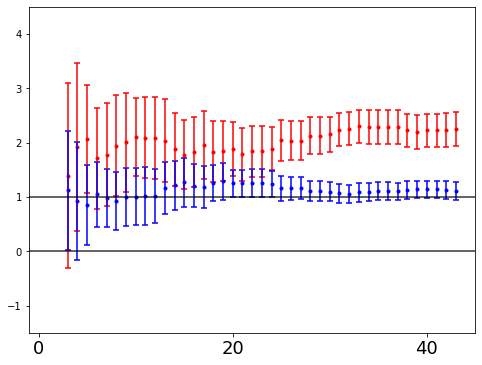

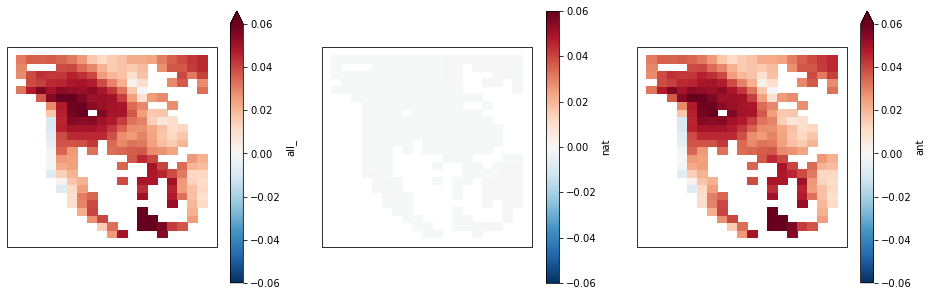

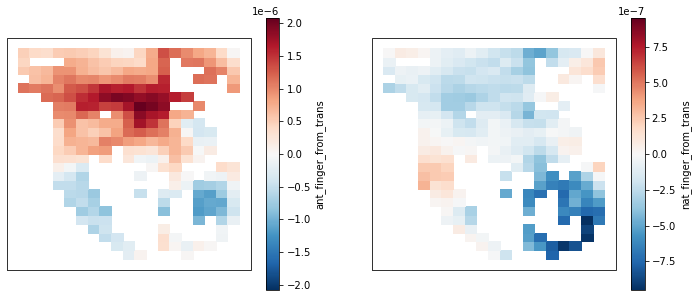

In [11]:
'''
MAIN function for performing optimal fingerprinting using cam5 and ERA5
'''

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 16,
        }



for i,model in enumerate(['cam5']):

    scen_dict = {'ALL':'All','NAT':'Nat'}
    range_dict = {'start':'1959','end':'2014'}
    vege_mask = cam5_vege_mask

    IDL.retall

    print('getting ALL mean and noise')
    all_ens_mean,noise_all = get_mean_and_noise(model, scen_dict['ALL'], box, vege_mask, range_dict['start'], range_dict['end'])
    print('getting NAT mean and noise')
    nat_ens_mean,noise_nat = get_mean_and_noise(model, scen_dict['NAT'], box, vege_mask, range_dict['start'], range_dict['end'])

    detrend_nat = detrend(nat_ens_mean,['time'])
    
    all_ens_mean = all_ens_mean.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
    all_ens_mean = all_ens_mean.dropna("pixel", how="all")# Drop the pixels that only have NA values.
    all_ens_mean = all_ens_mean.values.flatten()
    
    detrend_nat = detrend_nat.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
    detrend_nat = detrend_nat.dropna("pixel", how="all")# Drop the pixels that only have NA values.
    detrend_nat = detrend_nat.values.flatten()
    
    ant = all_ens_mean - detrend_nat
    
    print('getting obs')
    data_obs = get_obs_data(model, box, vege_mask, range_dict['start'], range_dict['end'])
    print('got obs')
    data_scen = np.array([all_ens_mean,detrend_nat])

    data_noise_1 = np.concatenate((noise_all[:22],noise_nat[:24]))
    data_noise_2 = np.concatenate((noise_all[22:],noise_nat[24:]))

    print('got arrays')

    trunc = np.array([i for i in range(3,44)])

    IDL.data_obs = data_obs
    IDL.data_scen = data_scen
    IDL.data_noise_1 = data_noise_1
    IDL.data_noise_2 = data_noise_2
    IDL.trunc = trunc
    IDL.scan_beta_est = []
    IDL.scan_p_resid = []
    IDL.finger_trans = 1

    print('running gendetec')
    IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, scan_resid_sumsq=scan_resid_sumsq, \
            data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, scan_beta_est=scan_beta_est,\
            scan_p_resid=scan_p_resid, finger_trans=finger_trans")

    scan_beta_est = IDL.scan_beta_est
    scan_p_resid = IDL.scan_p_resid
    finger_trans = IDL.finger_trans

    #print(scan_beta_est)
    
    beta_df = save_result(scan_beta_est,trunc)
    
    fig,ax = plt.subplots(figsize=(8,6))#,gridspec_kw={'width_ratios': [1, 101/46]}, sharey=True)
    #ax = axs.flatten()
    
    plot_saved_result(beta_df,ax,font)
    plt.show()
    
    plot_maps(all_ens_mean, detrend_nat, ant)
    
    plot_fingerprints(finger_trans)


In [7]:
def get_obs_data(model, box, vege_mask, start_year, end_year):
    
    if model == 'cam5':
        model_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')
        era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
    else:
        model_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')
        era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')

    era5_da = era5_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
    era5_da = era5_da.where(vege_mask>0)
        
    era5_da = era5_da.sel(time=slice(start_year,end_year))
    era5_da = era5_da.where(~model_da.isnull())
    
    era5_da = era5_da.stack(pixel=("latitude", "longitude"))
    era5_da = era5_da.dropna("pixel", how="all")        
    
    array = era5_da.values.flatten()
    
    #del era5_da
    
    return(array)


In [8]:
def get_noise(model,era5_da,scen,ens_mean,box,vege_mask,start_year,end_year):
    
    if model == 'cam5':
        runs = {'All':[i for i in range(1,11)] + [i for i in range(36,44)] + [i for i in range(61,71)] + [i for i in range(86,101)],
                'Nat':[i for i in range(1,11)] + [i for i in range(36,51)] + [i for i in range(61,71)] + [i for i in range(86,96)] + [i for i in range(97,101)]}
    else:
        runs = {'HPB':range(1,101),
                'HPB_NAT':range(1,101)}
    noise = []
    for ens_mem in runs[scen]:
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

        if model == 'cam5':
            mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_'+scen+'_run'+number+'.nc')
        elif model == 'd4pdf':
            mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_'+scen+'_m'+number+'.nc')

        mem_da = mem_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        mem_da = mem_da.where(vege_mask>0)

        mem_da = mem_da.sel(time=slice(start_year,end_year))
        mem_da = mem_da.where(~era5_da.isnull())

        diff = mem_da - ens_mean

        diff = diff.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
        diff = diff.dropna("pixel", how="all")# Drop the pixels that only have NA values.
                
        diff_array = diff.values.flatten()
        noise.append(diff_array)
        
    return(noise)


In [9]:
def get_mean_and_noise(model, scen, box, vege_mask, start_year, end_year):
    
    if model == 'cam5':
        era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
        ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_'+scen+'_ensMean.nc')
    else:
        era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
        ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_'+scen+'_ensMean.nc')
    
    ens_mean = ens_mean.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
    ens_mean = ens_mean.where(vege_mask>0)
        
    ens_mean = ens_mean.sel(time=slice(start_year,end_year))
    ens_mean = ens_mean.where(~era5_da.isnull())
    
    noise = get_noise(model,era5_da,scen,ens_mean,box,vege_mask,start_year,end_year)

    #ens_mean = ens_mean.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
    #ens_mean = ens_mean.dropna("pixel", how="all")# Drop the pixels that only have NA values.
    #ens_mean_array = ens_mean.values.flatten()
    
    return((ens_mean, np.array(noise)))


In [10]:
def save_result(scan_beta_est,trunc):

    df_dict = {'Truncation':trunc,'ant_best':[],'ant_lower':[],'ant_upper':[],'nat_best':[],'nat_lower':[],'nat_upper':[]}
    
    for j in range(len(scan_beta_est)):

        beta_est = scan_beta_est[j]

        df_dict['ant_best'].append(beta_est[0][0])
        df_dict['ant_lower'].append(beta_est[1][0])
        df_dict['ant_upper'].append(beta_est[2][0])
        
        df_dict['nat_best'].append(beta_est[0][1])
        df_dict['nat_lower'].append(beta_est[1][1])
        df_dict['nat_upper'].append(beta_est[2][1])
        
    df = pd.DataFrame.from_dict(df_dict)
    
    return(df)